In [5]:
import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/ovigupta/gdpdata/gdp.csv


In [6]:
df=pd.read_csv("/kaggle/input/datasets/ovigupta/gdpdata/gdp.csv")

In [5]:
df.head()

,Country Name,Country Code,Year,Value
0,Arab World,ARB,1968,2.576068e+10
1,Arab World,ARB,1969,2.843420e+10
2,Arab World,ARB,1970,3.138550e+10
3,Arab World,ARB,1971,3.642691e+10
4,Arab World,ARB,1972,4.331606e+10


# **1) How many unique Countries Data we're having in the dataset?**

In [6]:
df['Country Name'].nunique()

256

# **2) How many years of Data we're having for India**

In [7]:
df[df['Country Name']=='India']['Year'].nunique()

57

# **3) Whats the world GDP in 1969?**

In [12]:
df[df['Year'] == 1969]['Value'].sum()

np.float64(19577201579296.54)

# **4) Whats the % of GDP growth of India in Year 1994 (*as compare to 1993)?***

In [17]:
india = df[df['Country Name'] == 'India']
gdp_1993= india[india['Year']==1993]['Value'].iloc[0]
gdp_1994= india[india['Year']==1994]['Value'].iloc[0]
gdp= ((gdp_1994 - gdp_1993)/gdp_1993)*100
print(gdp)

17.178748210146075


# **Find GDP Growth of India from 1960 - 2016**

In [20]:
gdp_1960= india[india['Year']==1960]['Value'].iloc[0]
gdp_2016= india[india['Year']==2016]['Value'].iloc[0]
gdp_india= (gdp_2016 - gdp_1960)/gdp_1960 * 100
print(gdp_india)

6096.072762594173


# **Create a graph of GDP Growth of India from 1960 - 2016**

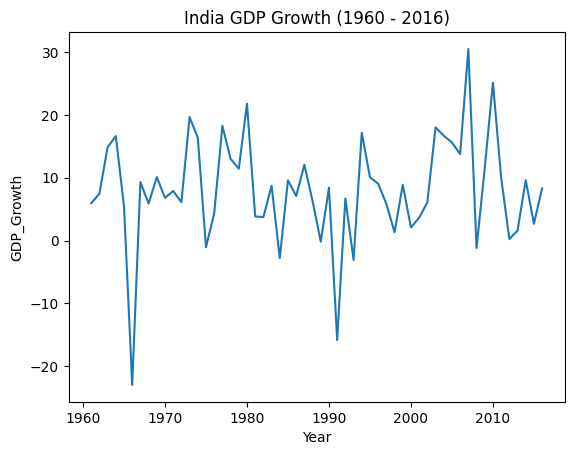

In [28]:
import seaborn as sns
india = df[df['Country Name'] == 'India'].copy()

india = india.sort_values('Year')

india['GDP_Growth'] = india['Value'].pct_change() * 100
sns.lineplot(data=india, x='Year', y='GDP_Growth')

plt.title("India GDP Growth (1960 - 2016)")
plt.show()

# **Create a new columns named as GDP which shows the GDP growth of each country for that year**

In [25]:
df = df.sort_values(['Country Name', 'Year'])
df['GDP']= df.groupby('Country Name')['Value'].pct_change()*100
df.head()

,Country Name,Country Code,Year,Value,GDP
2306,Afghanistan,AFG,1960,5.377778e+08,NaN
2307,Afghanistan,AFG,1961,5.488889e+08,2.066111
2308,Afghanistan,AFG,1962,5.466667e+08,-0.404857
2309,Afghanistan,AFG,1963,7.511112e+08,37.398386
2310,Afghanistan,AFG,1964,8.000000e+08,6.508870
